## **Modelos com Implementação Própria, NumPy**

**Tarefa 2 do Trabalho Prático — Aprendizagem Profunda**

Notebook que implementa e compara modelos de classificação de texto (Human vs AI) usando apenas NumPy:

1. **Baseline — Regressão Logística Multi-Classe** (Softmax Regression)
2. **DNN — Deep Neural Network** com várias arquiteturas
3. **Comparação de técnicas de regularização** (Dropout vs L2 vs ambos)
4. **Avaliação final** com métricas, curvas de aprendizagem e matrizes de confusão

### **1. Imports e Carregamento dos Dados**

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, time

# Adicionar o caminho para o diretório src
sys.path.append(os.path.abspath('../src'))

# Modelos from scratch
from neuralnet import NeuralNetwork
from layers import DenseLayer, DropoutLayer
from activations import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy
from optimizer import Adam, SGD
from logisticregression import LogisticRegression

# Pipeline de features (NumPy puro)
from utils import prepare_text_data, transform_new_texts

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

### **2. Preparação dos Dados**

In [33]:
print("A carregar os datasets...")

# Dataset de treino e validação
df_train_val = pd.read_csv('../data/dataset.csv', sep=';')
df_train_val.columns = df_train_val.columns.str.lower()
textos_train_val = df_train_val['text'].tolist()
labels_train_val = df_train_val['label'].tolist()

# Dataset de teste
df_test = pd.read_csv('../data/raw/dataset-exemplos.csv', sep=';')
df_test.columns = df_test.columns.str.lower()
textos_test = df_test['text'].tolist()
labels_test = df_test['label'].tolist()

print(f"  Dataset de treino e validação: {len(textos_train_val)} textos")
print(f"  Dataset de teste: {len(textos_test)} textos")

print("\nA processar features (TF-IDF word + char + estilísticas)...")
X_train, Y_train, X_val, Y_val, transformers, encoder = prepare_text_data(
    textos_train_val,
    labels_train_val,
    max_features=1500,    
    char_features=1500,   
    use_stratify=True,
    ngram_range=(1, 2)
)

print("A processar features do dataset de teste...")
X_test = transform_new_texts(textos_test, transformers)
Y_test = encoder.transform(np.array(labels_test))

input_dim = X_train.shape[1]
output_dim = Y_train.shape[1]
class_names = encoder.classes

print(f"\n✅ Dados prontos:")
print(f"  Treino:    {X_train.shape}")
print(f"  Validação: {X_val.shape}")
print(f"  Teste:     {X_test.shape}")
print(f"  Classes:   {list(class_names)}")
print(f"  Rácio features/amostras: {input_dim/X_train.shape[0]:.2f}")

A carregar os datasets...
  Dataset de treino e validação: 5000 textos
  Dataset de teste: 125 textos

A processar features (TF-IDF word + char + estilísticas)...
A processar features do dataset de teste...

✅ Dados prontos:
  Treino:    (4000, 3013)
  Validação: (1000, 3013)
  Teste:     (125, 3013)
  Classes:   [np.str_('Anthropic'), np.str_('Google'), np.str_('Human'), np.str_('Meta'), np.str_('OpenAI')]
  Rácio features/amostras: 0.75


### **3. Baseline — Regressão Logística Multi-Classe (Softmax)**

O enunciado exige um modelo baseline de regressão logística. Implementámos uma Softmax Regression
(generalização multi-classe da regressão logística binária) com:
- Categorical Cross-Entropy como função de custo
- Mini-batch gradient descent
- Regularização L2
- Early stopping

In [34]:
np.random.seed(42)

print("Baseline: Regressão Logística Multi-Classe")

lr_model = LogisticRegression(
    n_features=input_dim,
    n_classes=output_dim,
    learning_rate=0.05,
    l2_lambda=0.001
)

t0 = time.time()
lr_model.fit(
    X_train, Y_train,
    epochs=300,
    batch_size=64,
    verbose=True,
    X_val=X_val, Y_val=Y_val,
    patience=15
)
tempo_lr = time.time() - t0

# Avaliar
lr_train_loss, lr_train_acc = lr_model.evaluate(X_train, Y_train)
lr_val_loss, lr_val_acc = lr_model.evaluate(X_val, Y_val)
lr_test_loss, lr_test_acc = lr_model.evaluate(X_test, Y_test)

print(f"\nResultados da baseline:")
print(f"  Treino      — Loss: {lr_train_loss:.4f} | Accuracy: {lr_train_acc:.2%}")
print(f"  Validação   — Loss: {lr_val_loss:.4f} | Accuracy: {lr_val_acc:.2%}")
print(f"  Teste       — Loss: {lr_test_loss:.4f} | Accuracy: {lr_test_acc:.2%}")
print(f"  Tempo: {tempo_lr:.1f}s")

Baseline: Regressão Logística Multi-Classe
Epoch    1/300 | Loss: 1.2040 | Val Loss: 1.2102 | Acc: 53.75% | Val Acc: 51.50%
Epoch   11/300 | Loss: 1.0278 | Val Loss: 1.0532 | Acc: 59.58% | Val Acc: 56.40%
Epoch   21/300 | Loss: 0.9918 | Val Loss: 1.0263 | Acc: 61.25% | Val Acc: 58.90%
Epoch   31/300 | Loss: 0.9629 | Val Loss: 1.0036 | Acc: 63.55% | Val Acc: 60.50%
Epoch   41/300 | Loss: 0.9372 | Val Loss: 0.9839 | Acc: 65.70% | Val Acc: 62.00%
Epoch   51/300 | Loss: 0.9135 | Val Loss: 0.9655 | Acc: 67.07% | Val Acc: 63.30%
Epoch   61/300 | Loss: 0.8912 | Val Loss: 0.9488 | Acc: 68.42% | Val Acc: 64.50%
Epoch   71/300 | Loss: 0.8704 | Val Loss: 0.9330 | Acc: 69.77% | Val Acc: 65.40%
Epoch   81/300 | Loss: 0.8507 | Val Loss: 0.9174 | Acc: 70.93% | Val Acc: 66.20%
Epoch   91/300 | Loss: 0.8322 | Val Loss: 0.9032 | Acc: 72.08% | Val Acc: 67.30%
Epoch  101/300 | Loss: 0.8146 | Val Loss: 0.8903 | Acc: 72.95% | Val Acc: 67.60%
Epoch  111/300 | Loss: 0.7980 | Val Loss: 0.8770 | Acc: 74.25% | V

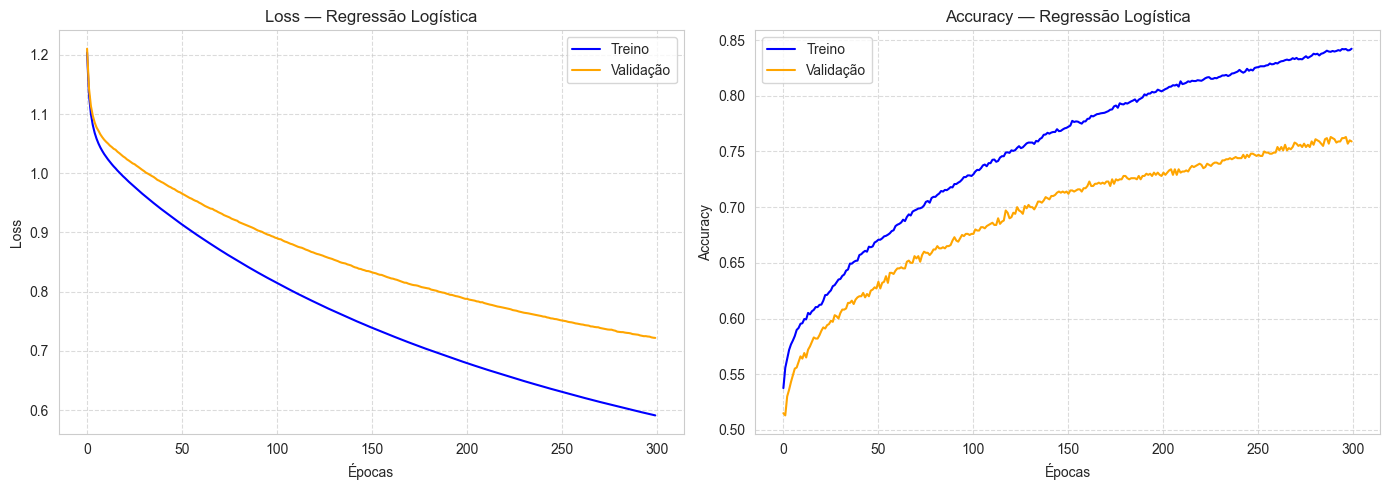

In [35]:
# Curvas de aprendizagem do Baseline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lr_model.history['loss'], label='Treino', color='blue')
axes[0].plot(lr_model.history['val_loss'], label='Validação', color='orange')
axes[0].set_title('Loss — Regressão Logística')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].plot(lr_model.history['acc'], label='Treino', color='blue')
axes[1].plot(lr_model.history['val_acc'], label='Validação', color='orange')
axes[1].set_title('Accuracy — Regressão Logística')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **4. Deep Neural Networks — Exploração de Arquiteturas**

Estratégia anti-overfitting aplicada a todas as DNNs:
- **Dimensionalidade reduzida** (~3013 features vs 6013 anteriores)
- **Arquiteturas bottleneck** — camadas mais estreitas forçam representações compactas
- **Regularização agressiva** — Dropout 0.5 e L2 0.01
- **Batch size 128** — gradientes mais estáveis
- **Patience 7** — early stopping mais apertado
- **Learning rate 0.0001** — convergência mais suave

Arquiteturas testadas:
- **DNN A** — Bottleneck: 128 → 32 → 5
- **DNN B** — Profunda estreita: 128 → 64 → 32 → 5
- **DNN C** — Mínima: 64 → 16 → 5

In [36]:
def treinar_dnn(nome, camadas_config, epochs=300, batch_size=128, patience=7,
                lr=0.0001):
    """
    Constrói e treina uma DNN a partir de uma lista de configurações de camadas.
    
    camadas_config: lista de tuplos (n_units, dropout_rate, l2_lambda)
        Ex: [(128, 0.5, 0.01), (32, 0.5, 0.01)] = 2 hidden layers
    """
    np.random.seed(42)
    adam = Adam(learning_rate=lr)
    nn = NeuralNetwork(loss_func=CategoricalCrossEntropy())
    
    prev_units = input_dim
    for n_units, dropout, l2 in camadas_config:
        nn.add(DenseLayer(input_shape=prev_units, n_units=n_units, optimizer=adam, l2_lambda=l2))
        nn.add(ReLUActivation())
        if dropout > 0:
            nn.add(DropoutLayer(rate=dropout))
        prev_units = n_units
    
    # Camada de saída
    nn.add(DenseLayer(input_shape=prev_units, n_units=output_dim, optimizer=adam))
    nn.add(SoftmaxActivation())
    
    desc = " → ".join([str(c[0]) for c in camadas_config]) + f" → {output_dim}"
    print(f"{nome}: {desc}")
    
    t0 = time.time()
    nn.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size,
           verbose=True, X_val=X_val, Y_val=Y_val, patience=patience)
    tempo = time.time() - t0
    
    train_loss, train_acc = nn.evaluate(X_train, Y_train)
    val_loss, val_acc = nn.evaluate(X_val, Y_val)
    test_loss, test_acc = nn.evaluate(X_test, Y_test)
    
    print(f"\n  Treino    — Acc: {train_acc:.2%}")
    print(f"  Validação — Acc: {val_acc:.2%}")
    print(f"  Teste     — Acc: {test_acc:.2%}")
    print(f"  Tempo: {tempo:.1f}s")
    
    return nn, {
        'nome': nome,
        'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc,
        'train_loss': train_loss, 'val_loss': val_loss, 'test_loss': test_loss,
        'tempo': tempo, 'history': nn.history
    }

In [37]:
# Treinar as 3 arquiteturas
resultados = {}

# DNN A — Bottleneck (128 → 32)
nn_a, res_a = treinar_dnn("DNN A (128→32)", [
    (128, 0.5, 0.01),
    (32,  0.5, 0.01),
])
resultados['DNN A'] = res_a

# DNN B — Profunda estreita (128 → 64 → 32)
nn_b, res_b = treinar_dnn("DNN B (128→64→32)", [
    (128, 0.5, 0.01),
    (64,  0.5, 0.01),
    (32,  0.5, 0.01),
])
resultados['DNN B'] = res_b

# DNN C — Mínima (64 → 16)
nn_c, res_c = treinar_dnn("DNN C (64→16)", [
    (64, 0.5, 0.01),
    (16, 0.5, 0.01),
])
resultados['DNN C'] = res_c

DNN A (128→32): 128 → 32 → 5
Epoch 1/300 | Loss: 1.5678 | Val Loss: 1.5710 | Train Acc: 36.35% | Val Acc: 33.60%
Epoch 11/300 | Loss: 1.1740 | Val Loss: 1.2007 | Train Acc: 56.67% | Val Acc: 53.90%
Epoch 21/300 | Loss: 1.0054 | Val Loss: 1.0535 | Train Acc: 62.82% | Val Acc: 58.30%
Epoch 31/300 | Loss: 0.9211 | Val Loss: 0.9850 | Train Acc: 66.62% | Val Acc: 61.90%
Epoch 41/300 | Loss: 0.8613 | Val Loss: 0.9379 | Train Acc: 68.30% | Val Acc: 63.80%
Epoch 51/300 | Loss: 0.8178 | Val Loss: 0.9049 | Train Acc: 71.38% | Val Acc: 65.70%
Epoch 61/300 | Loss: 0.7804 | Val Loss: 0.8745 | Train Acc: 73.72% | Val Acc: 66.70%
Epoch 71/300 | Loss: 0.7445 | Val Loss: 0.8486 | Train Acc: 75.58% | Val Acc: 67.80%
Epoch 81/300 | Loss: 0.7124 | Val Loss: 0.8235 | Train Acc: 77.95% | Val Acc: 69.70%
Epoch 91/300 | Loss: 0.6769 | Val Loss: 0.7971 | Train Acc: 80.00% | Val Acc: 71.90%
Epoch 101/300 | Loss: 0.6480 | Val Loss: 0.7768 | Train Acc: 83.12% | Val Acc: 73.70%
Epoch 111/300 | Loss: 0.6165 | Val L

### **5. Comparação de Regularização**

Usando a arquitetura bottleneck (128 → 32), comparamos:
- **Dropout only** (sem weight decay)
- **L2 only** (weight decay forte, sem Dropout)
- **Dropout + L2** (já testado acima como DNN A)

In [38]:
# Dropout only (sem L2)
nn_drop, res_drop = treinar_dnn("DNN Dropout Only", [
    (128, 0.5, 0.0),
    (32,  0.5, 0.0),
])
resultados['DNN Dropout'] = res_drop

# L2 only (sem Dropout)
nn_l2, res_l2 = treinar_dnn("DNN L2 Only", [
    (128, 0.0, 0.01),
    (32,  0.0, 0.01),
])
resultados['DNN L2'] = res_l2

# Dropout moderado (0.3) — menos agressivo, melhor generalização
nn_mod, res_mod = treinar_dnn("DNN Moderate", [
    (128, 0.3, 0.0),
    (32,  0.3, 0.0),
])
resultados['DNN Moderate'] = res_mod


DNN Dropout Only: 128 → 32 → 5
Epoch 1/300 | Loss: 1.5633 | Val Loss: 1.5669 | Train Acc: 37.55% | Val Acc: 34.30%
Epoch 11/300 | Loss: 1.1164 | Val Loss: 1.1538 | Train Acc: 59.65% | Val Acc: 55.80%
Epoch 21/300 | Loss: 0.8905 | Val Loss: 0.9639 | Train Acc: 69.65% | Val Acc: 64.60%
Epoch 31/300 | Loss: 0.7422 | Val Loss: 0.8482 | Train Acc: 76.95% | Val Acc: 70.30%
Epoch 41/300 | Loss: 0.6120 | Val Loss: 0.7510 | Train Acc: 83.15% | Val Acc: 74.40%
Epoch 51/300 | Loss: 0.4991 | Val Loss: 0.6708 | Train Acc: 88.22% | Val Acc: 77.50%
Epoch 61/300 | Loss: 0.4030 | Val Loss: 0.6039 | Train Acc: 91.70% | Val Acc: 80.20%
Epoch 71/300 | Loss: 0.3225 | Val Loss: 0.5571 | Train Acc: 93.23% | Val Acc: 80.70%
Epoch 81/300 | Loss: 0.2599 | Val Loss: 0.5218 | Train Acc: 94.97% | Val Acc: 81.40%
Epoch 91/300 | Loss: 0.2085 | Val Loss: 0.4962 | Train Acc: 96.47% | Val Acc: 81.70%
Epoch 101/300 | Loss: 0.1657 | Val Loss: 0.4795 | Train Acc: 97.60% | Val Acc: 82.40%
Epoch 111/300 | Loss: 0.1317 | Val

### **6. Curvas de Aprendizagem**

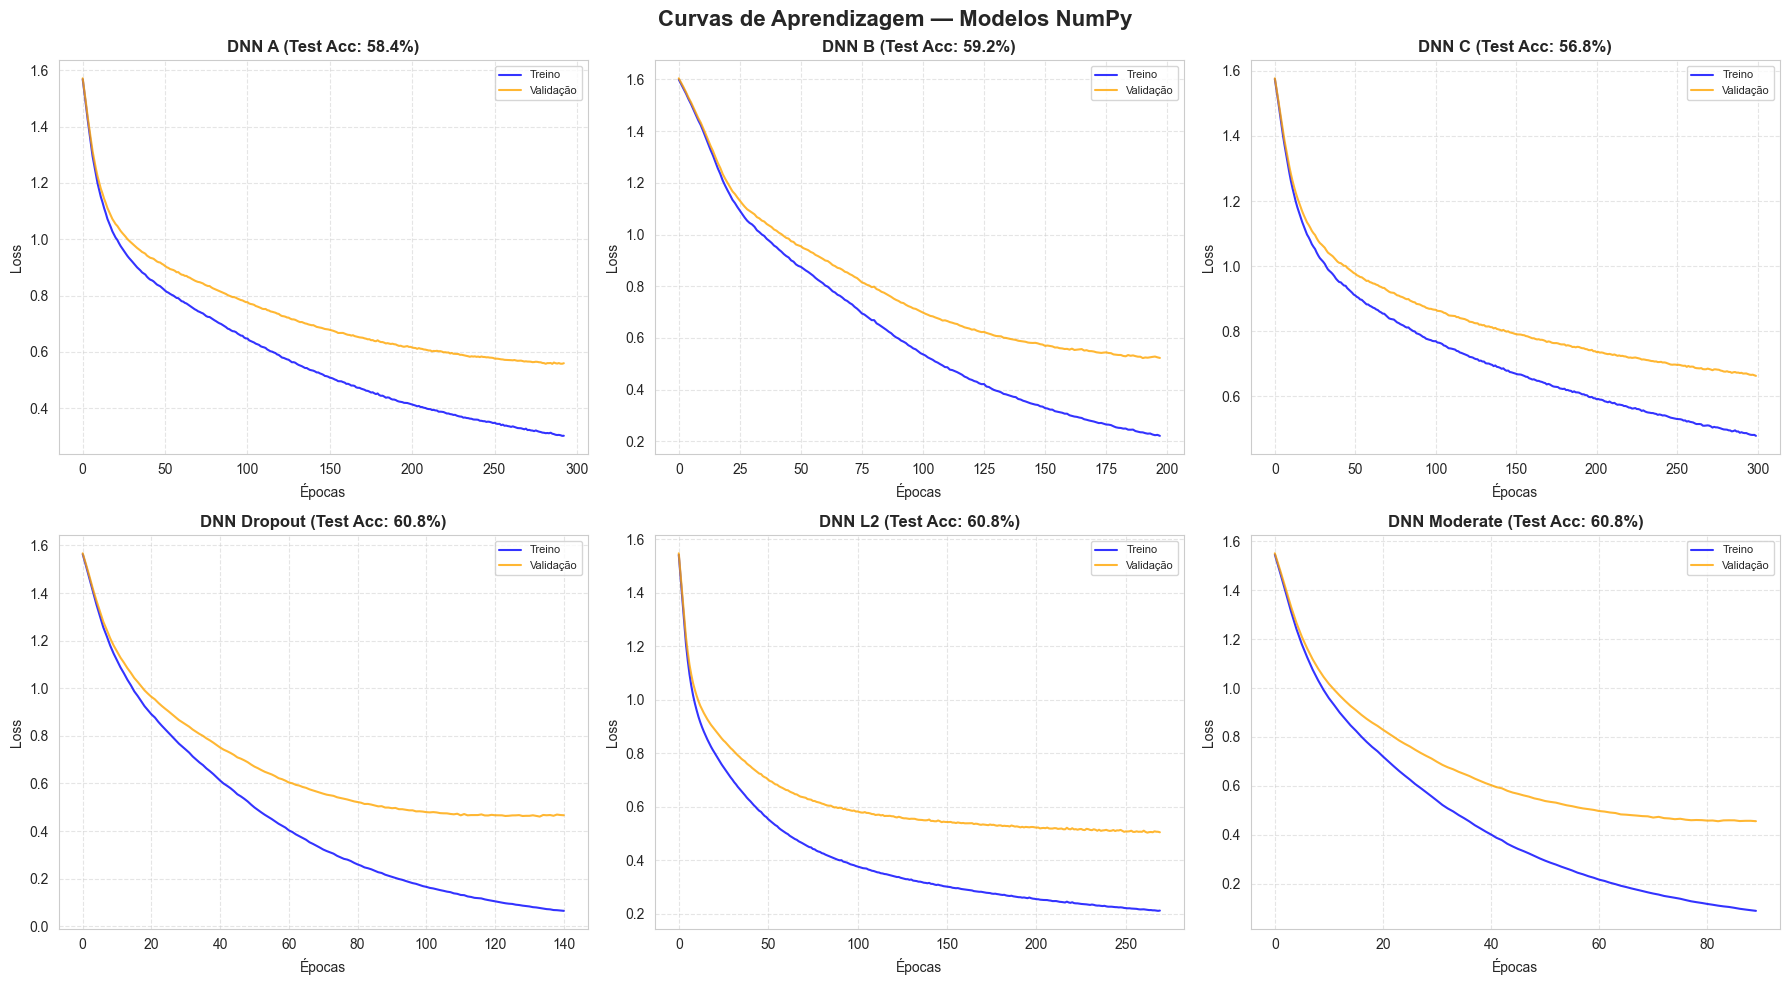

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

modelos_plot = [
    ('DNN A', res_a), ('DNN B', res_b), ('DNN C', res_c),
    ('DNN Dropout', res_drop), ('DNN L2', res_l2),
    ('DNN Moderate', res_mod),
]

for idx, (nome, res) in enumerate(modelos_plot):
    ax = axes[idx // 3][idx % 3]
    ax.plot(res['history']['loss'], label='Treino', color='blue', alpha=0.8)
    ax.plot(res['history']['val_loss'], label='Validação', color='orange', alpha=0.8)
    ax.set_title(f"{nome} (Test Acc: {res['test_acc']:.1%})", fontweight='bold')
    ax.set_xlabel('Épocas')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)


plt.suptitle('Curvas de Aprendizagem — Modelos NumPy', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **7. Comparação de Todos os Modelos**

In [40]:
# Adicionar o baseline à comparação
resultados['Baseline LR'] = {
    'nome': 'Baseline LR',
    'train_acc': lr_train_acc, 'val_acc': lr_val_acc, 'test_acc': lr_test_acc,
    'train_loss': lr_train_loss, 'val_loss': lr_val_loss, 'test_loss': lr_test_loss,
    'tempo': tempo_lr
}

# Construir tabela
rows = []
for key, res in resultados.items():
    rows.append({
        'Modelo': res['nome'],
        'Train Acc': f"{res['train_acc']:.2%}",
        'Val Acc': f"{res['val_acc']:.2%}",
        'Test Acc': f"{res['test_acc']:.2%}",
        'Test Loss': f"{res['test_loss']:.4f}",
        'Tempo (s)': f"{res['tempo']:.1f}",
    })

df_resultados = pd.DataFrame(rows)
df_resultados = df_resultados.sort_values('Test Acc', ascending=False)
print(df_resultados.to_string(index=False))

           Modelo Train Acc Val Acc Test Acc Test Loss Tempo (s)
 DNN Dropout Only    99.33%  83.00%   60.80%    1.7782     164.4
      DNN L2 Only    98.08%  81.70%   60.80%    1.3145     334.7
     DNN Moderate    98.80%  82.50%   60.80%    1.4590      80.3
      Baseline LR    84.23%  75.90%   60.80%    1.3258      21.8
DNN B (128→64→32)    97.67%  80.50%   59.20%    1.5700     243.3
   DNN A (128→32)    95.53%  80.70%   58.40%    1.3194     301.6
    DNN C (64→16)    91.75%  78.50%   56.80%    1.3674     237.3


### **8. Avaliação do Melhor Modelo**

In [41]:
# Selecionar o melhor modelo pelo test_acc
melhor_key = max(resultados, key=lambda k: resultados[k]['test_acc'])
print(f"🏆 Melhor modelo: {resultados[melhor_key]['nome']}")

# Encontrar o objeto do modelo correspondente
modelos_obj = {
    'DNN A': nn_a, 'DNN B': nn_b, 'DNN C': nn_c,
    'DNN Dropout': nn_drop, 'DNN L2': nn_l2,
    'DNN Moderate': nn_mod
}

if melhor_key == 'Baseline LR':
    y_pred_test = lr_model.predict(X_test)
    y_true_test = np.argmax(Y_test, axis=1)
else:
    melhor_nn = modelos_obj[melhor_key]
    y_pred_proba = melhor_nn.predict(X_test)
    y_pred_test = np.argmax(y_pred_proba, axis=1)
    y_true_test = np.argmax(Y_test, axis=1)

🏆 Melhor modelo: DNN Dropout Only


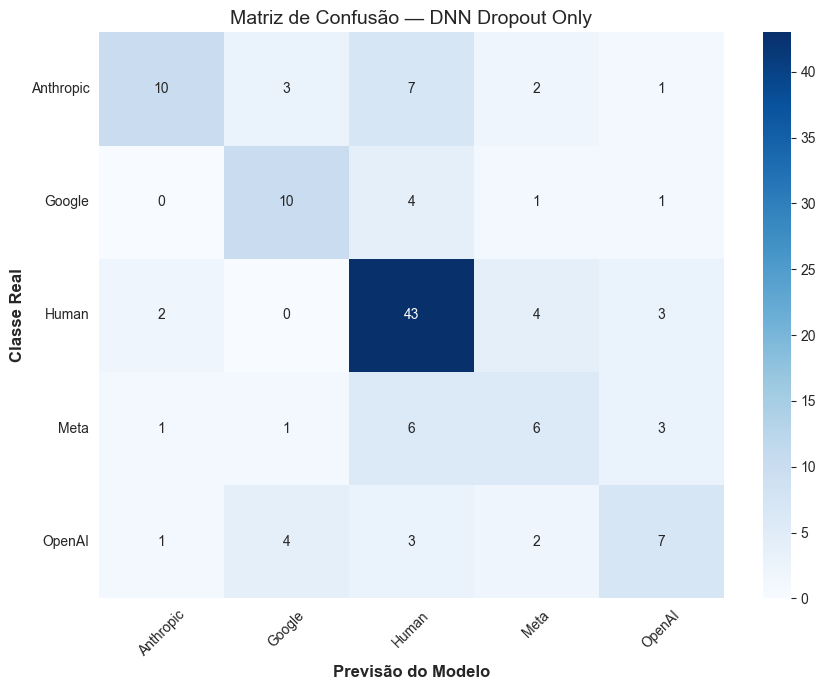


Classification Report — DNN Dropout Only:
              precision    recall  f1-score   support

   Anthropic       0.71      0.43      0.54        23
      Google       0.56      0.62      0.59        16
       Human       0.68      0.83      0.75        52
        Meta       0.40      0.35      0.38        17
      OpenAI       0.47      0.41      0.44        17

    accuracy                           0.61       125
   macro avg       0.56      0.53      0.54       125
weighted avg       0.60      0.61      0.60       125



In [42]:
# Matriz de Confusão
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão do Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Classe Real', fontsize=12, fontweight='bold')
plt.title(f'Matriz de Confusão — {resultados[melhor_key]["nome"]}', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification Report
print(f"\nClassification Report — {resultados[melhor_key]['nome']}:")
print(classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0))

### **9. Guardar o Modelo**

In [43]:
import pickle

# Guardar o melhor modelo + transformadores para submissão
modelo_para_guardar = {
    'modelo_tipo': melhor_key,
    'transformers': transformers,
    'encoder': encoder,
    'class_names': class_names,
}

if melhor_key == 'Baseline LR':
    modelo_para_guardar['weights'] = lr_model.weights
    modelo_para_guardar['biases'] = lr_model.biases
else:
    melhor_nn = modelos_obj[melhor_key]
    pesos = []
    for layer in melhor_nn.layers:
        if hasattr(layer, 'get_weights'):
            pesos.append(layer.get_weights())
        else:
            pesos.append(None)
    modelo_para_guardar['pesos_camadas'] = pesos

caminho = '../models/numpy.pkl'
os.makedirs('../models', exist_ok=True)
with open(caminho, 'wb') as f:
    pickle.dump(modelo_para_guardar, f)
    
print(f"✅ Modelo guardado em '{caminho}'")

✅ Modelo guardado em '../models/numpy.pkl'
